# QUBO feature selection

Reimplementation of Eq. (4) from Romero, Gupta, Gatlin, Chapkin, Cai,
*Quantum Machine Intelligence* (2025) 7:114, applied to GEO **GSE308682**.

$$
\min_{F} \left[ -\alpha \sum_{i} I_{i} F_{i} + (1-\alpha)\sum_{i,j} R_{ij} F_{i} F_{j} \right], \quad Q = (1-\alpha)R - \alpha\,\mathrm{diag}(I)
$$

Logic lives in `qubo_model.py`, `data_loader.py`, `qubo_experiment.py`. This notebook only configures and runs the experiment.

Set **`QUBO_DATA_DIR`** in the first code cell (or `export QUBO_DATA_DIR=...`) to the folder that contains:

- `GSE308682_filtered_matrix.mtx.gz`
- `GSE308682_filtered_features.tsv.gz`
- `GSE308682_filtered_barcodes.tsv.gz`
- `GSE308682_feature_reference.csv.gz`

Ocean tabu runs on the current kernel (including 3.14). **Kaiwu tabu needs Python 3.10**, not 3.1. A notebook cell cannot change the interpreter: create a 3.10 venv, register a kernel, then select **Python 3.10** in the kernel picker before running cell 1 (`pip install kaiwu==1.3.1` only runs on 3.10).

Comparison vs the paper: [`docs/compare-romero-2025.html`](docs/compare-romero-2025.html) · [中文](docs/compare-romero-2025.zh.html).


In [1]:
### setup local kaiwu_tabu env ###
# brew install python@3.10
# python3.10 -m venv .venv-py310
# source .venv-py310/bin/activate
# pip install -r requirements.txt
# pip install kaiwu==1.3.1 ipykernel
# python -m ipykernel install --user --name qubo-py310 --display-name "Python 3.10 (Kaiwu)"
### then, select kernel -> Python 3.10 (Kaiwu)

### to run CI###
# select kernel -> Python 3.10 (Kaiwu) and pip install kaiwu==1.3.1。
# platform.qboson.com
# export KAIWU_USER_ID=USER_ID
# export KAIWU_SDK_CODE=ACCESS_KEY

In [2]:
import sys

print(f"Kernel Python {sys.version.split()[0]}  (Kaiwu official wheel needs 3.10.x)")
if sys.version_info[:2] != (3, 10):
    raise SystemExit(
        f"Need Python 3.10.x for Kaiwu (got {sys.version.split()[0]}). "
        "Select kernel Python 3.10 (Kaiwu)."
    )

%pip install -q numpy scikit-learn matplotlib seaborn dwave-ocean-sdk scanpy ipywidgets tqdm
%pip install -q kaiwu==1.3.1


Kernel Python 3.10.21  (Kaiwu official wheel needs 3.10.x)
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


In [11]:
%load_ext autoreload
%autoreload 2

import os
import sys
from pathlib import Path

# --- paths: set these before loading real data ---
# QUBO_REPO_DIR: folder that contains qubo_model.py (default: notebook cwd).
os.environ.setdefault("QUBO_REPO_DIR", str(Path.cwd()))
# QUBO_DATA_DIR: folder with GEO GSE308682 10x files:
#   GSE308682_filtered_matrix.mtx.gz
#   GSE308682_filtered_features.tsv.gz
#   GSE308682_filtered_barcodes.tsv.gz
#   GSE308682_feature_reference.csv.gz
# Uncomment and edit, or export QUBO_DATA_DIR in the shell:
os.environ["QUBO_DATA_DIR"] = "/Users/***/Projects/sample_data"

ROOT = Path(os.environ["QUBO_REPO_DIR"]).expanduser().resolve()
if not (ROOT / "qubo_model.py").exists():
    raise FileNotFoundError(
        f"qubo_model.py not found in QUBO_REPO_DIR={ROOT}. "
        "Set os.environ['QUBO_REPO_DIR'] to this repository, or run the notebook from the repo root."
    )
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import numpy as np
from qubo_model import (
    HAS_DWAVE,
    HAS_KAIWU,
    HAS_TABU,
    available_solvers,
    compute_mutual_information_matrix,
    require_python_310,
    solve_qubo_target_k,
    solver_banner,
)
require_python_310()
from qubo_experiment import (
    compare_kaiwu_tabu_on_same_q,
    compare_with_lasso_rfr,
    load_experiment,
    print_regression_mse,
    target_cardinality,
)

print(f"Importing Python modules from {ROOT}")
print(f"QUBO_DATA_DIR={os.environ.get('QUBO_DATA_DIR', '(unset)')}")
print(f"Ocean tabu={HAS_TABU}, Ocean SA={HAS_DWAVE}, Kaiwu SDK={HAS_KAIWU}")


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Importing Python modules from /Users/jinshang/Projects/qubo
QUBO_DATA_DIR=/Users/jinshang/Projects/sample_data
Ocean tabu=True, Ocean SA=True, Kaiwu SDK=True


## Solvers

`dwave-ocean-sdk` is already used. **`tabu` / `sa` are classical CPU samplers**, not a QPU.
`leap` is D-Wave’s cloud hybrid solver. `kaiwu_cim` is QBoson’s photonic CIM.

| `SOLVER` | Stack | Hardware | Env |
| --- | --- | --- | --- |
| `tabu` | Ocean | classical CPU | — |
| `sa` | Ocean | classical CPU | — |
| `leap` | Ocean | Leap hybrid | `DWAVE_API_TOKEN` |
| `custom_sa` | this repo | classical CPU | — |
| `kaiwu_sa` / `kaiwu_tabu` | kaiwu SDK | classical CPU | **no CIM key** |
| `kaiwu_cim` | kaiwu CIM | photonic QPU | `KAIWU_USER_ID`, `KAIWU_SDK_CODE` |

`COMPARE_KAIWU_TABU` solves the **same** $Q$ with Ocean tabu vs Kaiwu tabu. Kaiwu tabu is local CPU. Official wheels target Python 3.10.


In [4]:
# Romero et al. §4.1-style settings. Implementations: data_loader.py, qubo_model.py
# T: "pseudotime" = scanpy DPT. "gene" = held-out RUNX1 Pearson residual.
# N_TOP_GENES: paper used ~5,000 HVGs. Pairwise MI is O(p²); tqdm shows progress.
# Tabu: Ocean default timeout is 20 ms/read (too small at p=5000). This repo
# overrides it; set QUBO_TABU_TIMEOUT_MS to change (milliseconds).
USE_REAL_DATA = True
N_TOP_GENES = 5000
TARGET_MODE = "pseudotime"
ROOT_GENE = "HBE1"          # DPT iroot = cell with min residual of this gene
SOLVER = "tabu"             # tabu | sa | leap | custom_sa | kaiwu_sa | kaiwu_tabu | kaiwu_cim
COMPARE_KAIWU_TABU = True   # same Q; kaiwu_tabu needs no CIM key
K_TARGET = 50               # paper real-data cardinality

import qubo_model as _qubo_model
print(solver_banner(SOLVER))
print("qubo_model loaded from", _qubo_model.__file__)
print("Available solvers:")
for name, meta in available_solvers().items():
    mark = "yes" if meta["installed"] else "no"
    print(f"  {name:12} installed={mark:3}  {meta['kind']:16}  {meta['stack']}")

X, y, true_features, feature_names = load_experiment(
    use_real_data=USE_REAL_DATA,
    n_top_genes=N_TOP_GENES,
    target_mode=TARGET_MODE,
    root_gene=ROOT_GENE,
)


D-Wave Ocean TabuSampler (classical, local; MATLAB tabu analog)
qubo_model loaded from /Users/jinshang/Projects/qubo/qubo_model.py
Available solvers:
  tabu         installed=yes  classical         dwave-ocean-sdk
  sa           installed=yes  classical         dwave-ocean-sdk
  leap         installed=yes  quantum-hybrid    dwave-ocean-sdk
  custom_sa    installed=yes  classical         this repo
  kaiwu_sa     installed=yes  classical         kaiwu SDK
  kaiwu_tabu   installed=yes  classical         kaiwu SDK
  kaiwu_cim    installed=yes  quantum           kaiwu CIM (QBoson photonic); kaiwu-pytorch-plugin optional


HVG residual variance: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 45/45 [00:01<00:00, 39.35it/s]


Computing Pearson residuals...


DPT: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 4/4 [00:16<00:00,  4.23s/it, dpt]

Target T: DPT (iroot=argmin HBE1 residual, cell 1523)
Real data (Pearson residuals): X=(10691, 5000), y=(10691,)
Feature names (first 10): ['HBE1', 'HBZ', 'VIM', 'HBG2', 'MALAT1', 'HIST1H1C', 'CA1', 'HBG1', 'CD24', 'DHRS2']


In [5]:
# Discrete MI: qubo_model.compute_mutual_information_matrix (tqdm on bins, I, R)
I, R = compute_mutual_information_matrix(X, y, n_bins=10)
print(f"Importance I (first 5): {I[:5]}")
print(f"Redundancy R (5x5):\n{R[:5, :5]}")


Redundancy R (pairwise MI): 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 5000/5000 [01:13<00:00, 68.40it/s]

Importance I (first 5): [0.5453377967 0.7152553907 0.1128618881 0.3738269612 0.0458965368]
Redundancy R (5x5):
[[0.           0.642316388  0.1833557985 0.4495039914 0.0590229915]
 [0.642316388  0.           0.2136880101 0.6941258969 0.0553276926]
 [0.1833557985 0.2136880101 0.           0.2162201768 0.0549126246]
 [0.4495039914 0.6941258969 0.2162201768 0.           0.049102921 ]
 [0.0590229915 0.0553276926 0.0549126246 0.049102921  0.          ]]


In [6]:
K = target_cardinality(X.shape[1], k=K_TARGET)
print(f"Target cardinality K={K}")


Target cardinality K=50


In [7]:
# Ocean tabu first, then (if COMPARE_KAIWU_TABU) Kaiwu tabu on the same Q.
# Kaiwu tabu is local CPU and does not need a CIM key. Skip if the SDK is not installed.


In [8]:
selected_features_qubo, energy, alpha, Q, report = solve_qubo_target_k(
    I, R, k=K, solver=SOLVER
)
selected_idx_qubo = np.where(selected_features_qubo == 1)[0]
print(f"α*={alpha:.4f}, energy={energy:.4f}, |F*|={len(selected_idx_qubo)}")
print(f"QUBO selected indices: {selected_idx_qubo}")
if feature_names is not None:
    print("QUBO selected genes:", [feature_names[i] for i in selected_idx_qubo])

# LASSO/RF stay at paper k. Never retarget them to a failed |F*|.
k_compare = K
if not report["accepted"]:
    print(
        f"WARNING: QUBO failed energy/cardinality acceptance "
        f"(energy={energy:.4f}, |F*|={len(selected_idx_qubo)}, k={K}). "
        "LASSO/RF below use target K, not |F*|. "
        "Do not treat MSE as proof that Eq. (4) was minimized."
    )
elif len(selected_idx_qubo) != K:
    print(
        f"WARNING: |F*|={len(selected_idx_qubo)} != target K={K} "
        "(within tolerance but not exact)."
    )

kaiwu_idx = None
if COMPARE_KAIWU_TABU:
    kaiwu_idx = compare_kaiwu_tabu_on_same_q(
        Q,
        selected_features_qubo,
        energy,
        k=K,
        feature_names=feature_names,
    )


Bisect α for |F*|≈k:   0%|                                                                                                                                                              | 0/16 [00:00<?, ?it/s]

TabuSampler: n=5000, num_reads=2, timeout=10000 ms/read (Ocean default is 20 ms), first initial state = all zeros


Bisect α for |F*|≈k:   6%|███████▎                                                                                                             | 1/16 [00:21<05:17, 21.20s/it, E=-3.05, alpha=0.5000, n_sel=77]

  α-bisect 1/16: α=0.500000  |F*|=77  energy=-3.0480  |n-k|=27
TabuSampler: n=5000, num_reads=2, timeout=10000 ms/read (Ocean default is 20 ms), first initial state = all zeros


Bisect α for |F*|≈k:  12%|██████████████▋                                                                                                      | 2/16 [00:42<04:55, 21.08s/it, E=-0.70, alpha=0.2500, n_sel=26]

...

Bisect α for |F*|≈k:  44%|███████████████████████████████████████████████████▏                                                                 | 7/16 [02:26<03:08, 20.90s/it, E=-1.82, alpha=0.3984, n_sel=51]

  α-bisect 7/16: α=0.398438  |F*|=51  energy=-1.8157  |n-k|=1
TabuSampler: n=5000, num_reads=2, timeout=10000 ms/read (Ocean default is 20 ms), first initial state = all zeros


Bisect α for |F*|≈k:  44%|███████████████████████████████████████████████████▏                                                                 | 7/16 [02:47<03:35, 23.90s/it, E=-1.78, alpha=0.3945, n_sel=50]

  α-bisect 8/16: α=0.394531  |F*|=50  energy=-1.7771  |n-k|=0
  kept best_alpha=0.394531 (|n-k|=0, E=-1.7771)


TabuSampler: n=5000, num_reads=8, timeout=10000 ms/read (Ocean default is 20 ms), first initial state = all zeros
QUBO acceptance:
  |F*|=50  target k=50  tol=5
  energy reported=-1.7771  recomputed FᵀQF=-1.7771
  empty mask energy=0  best singleton Q[1,1]=-0.2822
  one-bit moves that would lower E: turn_off=0  turn_on=0
  PASS: energy beats empty/singleton and cardinality is near k.
α*=0.3945, energy=-1.7771, |F*|=50
QUBO selected indices: [   0    1    3    5   14   27   30   32   36   64   80   81  150  272
  298  316  374  387  397  426  496  584  617  621  644  666  699  774
  781  879  886  929  932  978 1055 1135 1310 1335 1380 1603 1623 1677
 1815 2235 2246 2399 3229 3570 3650 4672]
QUBO selected genes: ['HBE1', 'HBZ', 'HBG2', 'HIST1H1C', 'MT-CO1', 'ALAS2', 'MTRNR2L8', 'HIST1H4C', 'SLC25A37', 'MT-ND1', 'MT-ND2', 'BLVRB', 'HBA2', 'RPL13A', 'RPLP0', 'MIF', 'EEF2', 'PRKAR2B', 'H3F3B', 'RPS2', 'NUP214', 'ODC1', 'CMBL', 'HMGA1', 'RANBP1', 'VAPA', 'SET', 'RPS20', 'ATP5B', 'RPL37A', '

LASSO path: α=0.0117, n_nonzero=49 (target K=50)
Fitting random forest (100 trees)...

=== Feature selection (K=50) ===
QUBO:                [0, 1, 3, 5, 14, 27, 30, 32, 36, 64, 80, 81, 150, 272, 298, 316, 374, 387, 397, 426, 496, 584, 617, 621, 644, 666, 699, 774, 781, 879, 886, 929, 932, 978, 1055, 1135, 1310, 1335, 1380, 1603, 1623, 1677, 1815, 2235, 2246, 2399, 3229, 3570, 3650, 4672]
LASSO:               [1, 31, 64, 80, 82, 272, 298, 312, 313, 374, 410, 426, 452, 461, 584, 604, 621, 624, 699, 750, 774, 781, 822, 879, 886, 929, 932, 950, 977, 978, 1020, 1055, 1108, 1149, 1274, 1310, 1332, 1335, 1623, 1677, 1815, 1954, 2399, 2543, 2568, 2935, 3199, 3449, 3905]
Random forest:       [0, 1, 2, 3, 6, 8, 14, 16, 19, 21, 27, 30, 31, 35, 38, 41, 46, 53, 64, 80, 89, 105, 164, 169, 180, 191, 212, 249, 272, 339, 348, 356, 410, 505, 621, 626, 647, 774, 924, 977, 1122, 2181, 2250, 2922, 3177, 3398, 4506, 4596, 4789, 4947]
Overlaps: Q∩L=24/50, Q∩RF=11/50, L∩RF=9/50, all3=6
QUBO genes:          [

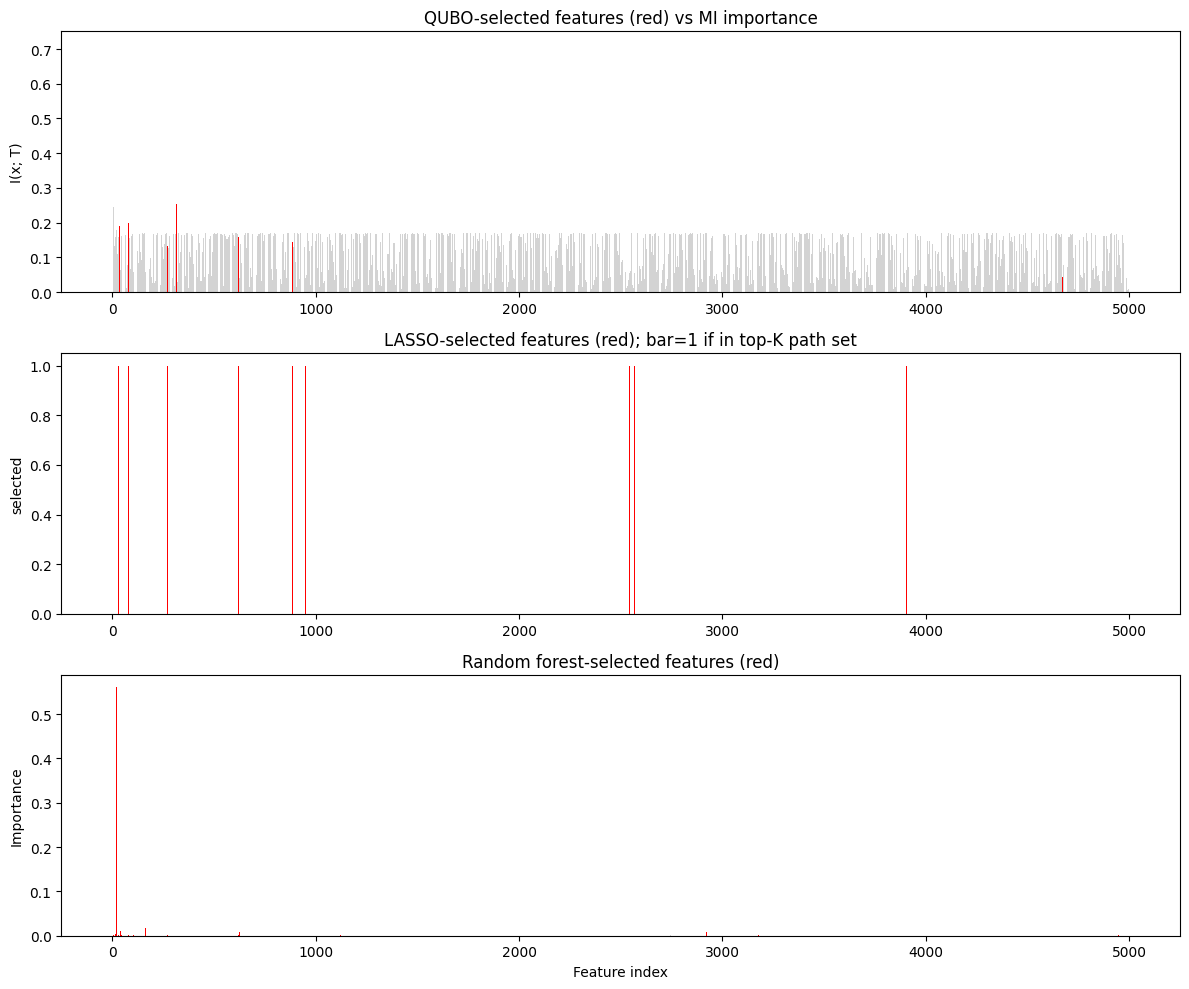

In [9]:
# LASSO path (~K nonzeros) and random forest. Overlaps printed here.
selected_idx_lasso, selected_idx_rf = compare_with_lasso_rfr(
    X, y, I, true_features, selected_idx_qubo, K=k_compare, feature_names=feature_names
)


In [12]:
extra = {}
if kaiwu_idx is not None:
    extra["QUBO Kaiwu tabu"] = kaiwu_idx
print_regression_mse(
    X, y, selected_idx_qubo, selected_idx_lasso, selected_idx_rf, extra=extra
)


Regression MSE (z-scored Ridge α=1):
  QUBO Ocean tabu (k=50): 0.0063
  QUBO Kaiwu tabu (k=52): 0.0061
  LASSO (k=49): 0.0048
  RF (k=50): 0.0064
  All features: 0.0091


## After a run

Open [`docs/compare-romero-2025.html`](docs/compare-romero-2025.html) or [中文](docs/compare-romero-2025.zh.html) for the last analyzed comparison vs the paper.

A healthy unconstrained Eq. (4) solve has **negative energy** and **|F\*| ≈ K** (50). Large positive energy with |F\*| ≈ p/2 means tabu/α-search failed to find a sparse minimizer — switch solver (`sa`, `leap`, `kaiwu_cim`) or inspect the α bisection tqdm postfix (`n_sel`).
